# Phase1: Data Loading and Exploratory Data Analysis (EDA)
**Goal:** My goal here is to get the raw falco alert data into a panda dataframe and look at what the data is like.

**Dataset:** [Falco-Alerts-Dataset-with-APT-attacks](https://github.com/simabagheri1/Falco-Alerts-Dataset-with-APT-attacks)  by Bagheri et al. (ICC 2023).

**Fetch Data:**

Make sure you are in the notebook, then run:
```bash
curl -L -o WARP_Falco_Alerts_Labeled_Dataset.zip https://raw.githubusercontent.com/simabagheri1/Falco-Alerts-Dataset-with-APT-attacks/master/WARP_Falco_Alerts_Labeled_Dataset.zip

unzip WARP_Falco_Alerts_Labeled_Dataset.zip
```

**Data Choice**: I noticed that in the set there is a file `Final_Balanced_Labled_Falco_Alerts_DS.json` which has been artificially balanced already but I decided to work with the `Collected_Alerts/Final Processed and Labeled Alerts` so I can perform my own balancing with class weighting/SMOTE.

## Initial Setup
```shell
source ~/miniconda3/etc/profile.d/conda.sh
conda create -n ai-ml-ca-env python=3.12 -y
conda activate ai-ml-ca-env
python -m pip instal -r requirements.txt
python -m ipykernel install --user --name ai-ml-ca-env --display-name "Python (ai-ml-ca-env)"
Jupyter notebook
```

## Imports
Import python packages, I need

In [1]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I prefer this style
sns.set_theme(style="whitegrid")

## Point the Data
Impoft the data of choice


In [2]:
# import os
# # os.getcwd()
# os.scandir(".")
# for entry in os.scandir("./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts"):
#     print(entry.name)

DATA_DIR = "./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts"
alert_json_files = sorted(glob.glob(f"{DATA_DIR}/*.json"))
print(f"Found {len(alert_json_files)} pod alert files:")
for f in alert_json_files:
    print (" -", f)

Found 10 pod alert files:
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-4xs77.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-544xc.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-bqwtm.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-cq4cs.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-j2xzj.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-jdbjh.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-qk6b5.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processed and Labeled Alerts/Alerts-Pod-sxchm.json
 - ./WARP_Falco_Alerts_Labeled_Dataset/Collected_Alerts/Final Processe

## Load the files into on table
Real all the json file into one big python list and then hand that list to pandas to turn it into a table.

We use pandas' `json_normalize` to flatten the nested alert json into normal table columns.

In [3]:
all_records = []
for filepath in alert_json_files:
    with open(filepath, encoding="utf-8") as f:
        records = json.load(f)
        # print(records[0])
        all_records.extend(records)

print("Total alert records loaded:", len(all_records))

# flatten the nested JSON into a table
df = pd.json_normalize(all_records)
print("Table shape (rows, columns):", df.shape)
# df.iloc[0]
df.head(2)


Total alert records loaded: 176649
Table shape (rows, columns): (176649, 36)


,output,priority,rule,source,tags,time,label,output_fields.container.id,output_fields.container.image.repository,output_fields.evt.time,...,output_fields.proc.pcmdline,output_fields.proc.aname[2],output_fields.proc.aname[3],output_fields.proc.aname[4],output_fields.proc.aname[5],output_fields.proc.aname[6],output_fields.proc.aname[7],output_fields.evt.arg.uid,output_fields.user.uid,output_fields.container.name
0,20:30:47.024077548: Notice A shell was spawned...,Notice,Terminal shell in container,syscall,"[container, mitre_execution, shell]",2021-11-19T20:30:47.024077548Z,normal,ef8ac1c64fa1,falcosecurity/falco,1637353847024077548,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20:31:16.488309915: Warning Shell history had ...,Warning,Delete or rename shell history,syscall,"[mitre_defense_evasion, process]",2021-11-19T20:31:16.488309915Z,normal,ef8ac1c64fa1,NaN,1637353876488309915,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Attack vs Normal Alerts
I need to figure out how imbalanced this data is. In real world we have a way more lower attacks compared to normal activities which is the challenge I am trying to mitigate with this EDA.


Normal: 175261 alerts (99.21%)
Attack: 1388 alerts (0.79%)


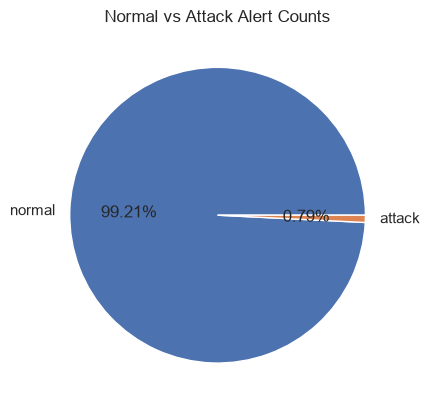

In [4]:
label_counts = df["label"].value_counts()
#print(label_counts)
percentage_of_normal = label_counts['normal'] / len(df) * 100
percentage_of_attack = label_counts['attack'] / len(df) * 100
# print(f"\nNormal: {percentage_of_normal}")
# print(f"\nAttack: {percentage_of_attack}")
print(f"\nNormal: {label_counts['normal']} alerts ({round(percentage_of_normal, 2)}%)")
print(f"Attack: {label_counts['attack']} alerts ({round(percentage_of_attack, 2)}%)")

label_counts.plot(
    kind="pie",
    color=["steelblue", "firebrick"],
    autopct="%1.2f%%"
)
plt.title("Normal vs Attack Alert Counts")
plt.ylabel("")
plt.show()


**What this tells us:** attack alerts are a tiny fraction of the data (well under 1%). If we trained a model and it predicts "normal" every single time, it would be a completely useless security tool, since it would never catch a real attack. It is better to misclassify a normal alert (false positve), than to miss a real attack (false negative). This is exactly why we can't just look at accuracy later on, and why we'll need SMOTE / class weighting when models are trained in later notebooks.

## What Falco Rules Triggered the Alerts?
Here looking at the `rules` column, I want to see which rule is  most common and if from a rule, I can know an attack.


In [5]:
print("Number of unique Falco rules:", df["rule"].nunique())
print()
print(df["rule"].value_counts())

Number of unique Falco rules: 22

rule
Launch Privileged Container                       31349
Launch Sensitive Mount Container                  27987
Modify binary dirs                                23186
Read sensitive file trusted after startup         11047
Read sensitive file untrusted                     10213
Run shell untrusted                                9973
Write below binary dir                             9789
System user interactive                            9378
System procs network activity                      9239
Create files below dev                             6873
Write below rpm database                           6466
Non sudo setuid                                    5736
DB program spawned process                         5705
Write below etc                                    3668
Mkdir binary dirs                                  3274
Write below root                                   2540
User mgmt binaries                                  104
Delete or

In [6]:
# for each rule, how many normal vs attack alerts did it produce?
rule_vs_label = pd.crosstab(df["rule"], df["label"])
rule_vs_label["attack_rate_in_%"] = (rule_vs_label["attack"] / (rule_vs_label["attack"] + rule_vs_label["normal"]) * 100).round(2)
rule_vs_label.sort_values("attack_rate_in_%", ascending=False)

label,attack,normal,attack_rate_in_%
rule,,,
Contact K8S API Server From Container,30,4,88.24
Terminal shell in container,9,15,37.50
Write below root,892,1648,35.12
Delete or rename shell history,6,48,11.11
User mgmt binaries,7,97,6.73
Launch Sensitive Mount Container,175,27812,0.63
Launch Privileged Container,194,31155,0.62
Write below binary dir,37,9752,0.38
Modify binary dirs,37,23149,0.16


**What this tells me:** I can see that no single rule is a perfect predictor of an attack. Even the strongest signal, `Contact K8S API Server From Container`, is only right 88% of the time, and the most frequent rules are dominated by normal traffic. So the rule alone is not enough to tell normal from attack alerts. The model has to learn from a combination of features.


## Priority Levels
Falco assigns each alert a priority level (Notice, Warning, Error, Critical, Debug), let's see how the alerts are distributed by priority levels.

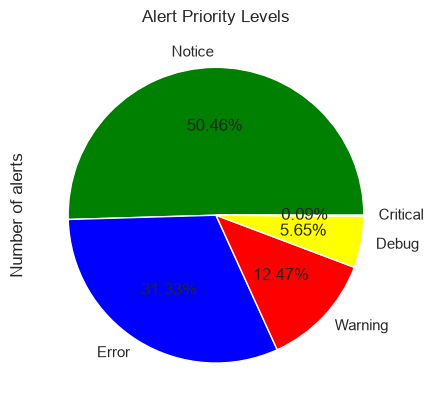

In [7]:

priority_counts = df["priority"].value_counts()
#print(priority_counts)
priority_counts.plot(kind="pie", colors=["green", "blue", "red", "yellow", "orange"], autopct="%1.2f%%")
plt.title("Alert Priority Levels")
plt.ylabel("Number of alerts")
plt.show()

### What Falco Priority Levels Trigger an Attack?
Let's see:

In [8]:
# for each priority level, how many normal vs attack alerts did it produce?
priority_vs_label = pd.crosstab(df["priority"], df["label"])
priority_vs_label["attack_rate_in_%"] = (
    priority_vs_label["attack"] / (priority_vs_label["attack"] + priority_vs_label["normal"]) * 100
).round(2)
priority_vs_label.sort_values("attack_rate_in_%", ascending=False)

label,attack,normal,attack_rate_in_%
priority,,,
Critical,158,0,100.00
Warning,718,21308,3.26
Error,512,54839,0.93
Debug,0,9973,0.00
Notice,0,89141,0.00


In [9]:
# Analysing Priority Level Vs Attack Cross-Table



total_attacks = priority_vs_label["attack"].sum()  # 158 + 718 + 512 = 1388
print(f"Total Attacks: {total_attacks}")

critical_attacks = priority_vs_label.loc["Critical", "attack"]  # 158
print(f"Critical Attacks: {critical_attacks}")

warning_error_attacks = priority_vs_label.loc[["Warning", "Error"], "attack"].sum()  # 1230
print(f"Warning+Error Attacks: {warning_error_attacks}")

notice_alerts = priority_vs_label.loc["Notice", "normal"].sum() #89141
notice_alert_share = round(notice_alerts / label_counts['normal'] * 100, 2)
print(f"Notice Alert Share (of all normal): {notice_alert_share}%")

critical_attack_share = round(critical_attacks / total_attacks * 100, 2)  # 11.38%
print(f"Critical Attack Share (of all attacks): {critical_attack_share}%")

warning_error_share = round(warning_error_attacks / total_attacks * 100, 2)  # 88.62%
print(f"Warning+Error Share (of all attacks): {warning_error_share}%")

# How rare are attacks WITHIN Warning+Error alerts specifically?
warning_error_total_alerts = priority_vs_label.loc[["Warning", "Error"], ["attack", "normal"]].sum().sum()
warning_error_attack_rate = round(warning_error_attacks / warning_error_total_alerts * 100, 2) # 1.59%
print(f"Attack Rate within Warning+Error alerts: {warning_error_attack_rate}%")

overall_attack_rate = round(df["label"].value_counts(normalize=True)["attack"] * 100, 2)
print(f"Overall (baseline) Attack Rate: {overall_attack_rate}%")

Total Attacks: 1388
Critical Attacks: 158
Warning+Error Attacks: 1230
Notice Alert Share (of all normal): 50.86%
Critical Attack Share (of all attacks): 11.38%
Warning+Error Share (of all attacks): 88.62%
Attack Rate within Warning+Error alerts: 1.59%
Overall (baseline) Attack Rate: 0.79%


**What this tells me:** In this dataset we see that priority level to an extent is a good indicator, but not for most of it. Every Critical alert (158 of them) is an attack, while Notice/Debug alerts are never attacks. But Critical alerts make up only 11.4% (approx. 1/10th) of all attacks in this dataset. The remaining 88.6% of the attacks, show up as Warning or Error priority, where only 1.59% of their alerts are actually attacks (1,230 out of 77,377), barely above the dataset's overall baseline attack rate of 0.79%. In other words, an attack at Warning/Error priority looks almost identical to the huge pool of normal Warning/Error alerts - priority alone gives almost no signal there. So priority is useful for a small slice of attacks, but not enough on its own. To catch the majority of attacks, the model needs to combine priority with other features.

## Missing Data
Let's also check how much data is missing in each column, some columns will be almost entirely empty because different Falco rules report different details.

In [10]:
# Get the number of missing cells per column
missing_count =  df.isna().sum()
#print(missing_count)

# For each column get the percentage of the missing cell over the total cells (total rows)
total_rows = len(df)
missing_pct = round((missing_count / total_rows) * 100, 1)

# Sort so the most-missing columns show up first
missing_pct = missing_pct.sort_values(ascending=False)

print("Percentage of missing values per column:")
print(missing_pct.head(40))

Percentage of missing values per column:
output_fields.evt.arg.name                  100.0
output_fields.proc.tty                      100.0
output_fields.proc.aname[7]                 100.0
output_fields.proc.aname[6]                 100.0
output_fields.proc.aname[5]                 100.0
output_fields.evt.arg.oldpath               100.0
output_fields.container.name                100.0
output_fields.evt.arg.path                   98.1
output_fields.user.uid                       96.8
output_fields.evt.arg.uid                    96.8
output_fields.proc.aname[3]                  94.3
output_fields.proc.aname[4]                  94.3
output_fields.proc.aname[2]                  88.0
output_fields.evt.args                       86.9
output_fields.evt.type                       86.9
output_fields.proc.name                      85.6
output_fields.container.mounts               84.3
output_fields.proc.pcmdline                  70.0
output_fields.fd.name                        66.6
output_fi

**What this tells us:** some columns like `priority`, `rule`, `time`, `proc.cmdline`, and `container.id` are filled in on almost every alert, so we can use them directly. Other columns like `proc.tty` and `evt.arg.name` are empty almost all the time. But that's not a mistake in the data, it's because different Falco rules report different details (a file alert won't have process info, and a process alert won't have file info). In next steps, we'll keep the columns that are almost always filled in, and for a few of the mostly-empty ones, we'll just track if the field is filled in or not as a simple yes/no feature instead of throwing the column away completely.